# Two-Tower LSTM: One-Hot vs Embedding Profile Tower (A/B)

Compares three identical two-tower LSTM models that differ **only** in how the profile categoricals
(`location`, `reg_channel`) are represented. LightGBM is deliberately **removed** — this notebook is LSTM-only.

| Variant | Profile categorical handling | Input dim |
|---|---|---|
| **A** (baseline, current) | one-hot `reg_channel` (5) + one-hot `location` (21) | 30 |
| **B** | one-hot `reg_channel` (5) + `Embedding(location, 4)` | 9 |
| **C** | `Embedding(location,4)` + `Embedding(reg_channel,3)` | 4 |

All embeddings are **trainable** (Keras default). Sequence tower `LSTM(8)` and the shared head
`Concat(8+16)->Dense32->Dense16->Dense8->Dense1(sigmoid)` are identical across variants.

A proper **train/val/test** 3-way split is used (this fixes the source notebook's `validation_data = train` leak),
so the train-vs-val ROC-AUC curves below are a genuine comparison.

**Hypothesis:** on this low-cardinality, long-tail, synthetic data, embeddings will not meaningfully beat one-hot.   
**Source:** https://github.com/ikatsov/tensor-house/tree/master

In [1]:
#
# Imports + reproducible seeds
#
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, LSTM, Input, Concatenate, Embedding, Flatten)
from tensorflow.keras.callbacks import Callback
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)
print(f"TF {tf.__version__} | Keras {tf.keras.__version__}")

TF 2.10.0 | Keras 2.10.0


In [ ]:
#
# Load data (same source as propensity-scoring-lstm)
#
DATA = DATA_PATH"
u = pd.read_csv(DATA + "users.csv.zip", compression="zip", index_col="uid", parse_dates=["reg_date"])
l = pd.read_csv(DATA + "usage_logs.csv.zip", compression="zip", index_col="uid", parse_dates=["date"]).drop(columns=["items"])
print("users", u.shape, "| logs", l.shape)

users (8979, 6) | logs (2324214, 4)


In [3]:
#
# Profiles: lifetime sums + tenure + gender one-hot + normalize (float-cast fix applied)
#
p = u.join(l.drop(columns="date").groupby("uid").agg("sum"), on="uid")
p["reg_days"] = (p["reg_date"].max() - p["reg_date"]).dt.days
p = pd.get_dummies(p, columns=["gender"]).drop(columns=["reg_date"])

def normalize(df, cols):
    for c in cols:
        df.loc[:, c] = (df[c].astype(float) - df[c].astype(float).min()) / (df[c].astype(float).max() - df[c].astype(float).min())
    return df

num_cols = ["age", "reg_days", "gender_female", "gender_male"]
F_num = normalize(p[num_cols].copy(), num_cols).values                      # (8979,4)
F_ch_one = pd.get_dummies(p["reg_channel"]).values.astype(np.float32)       # (8979,5)
F_loc_one = pd.get_dummies(p["location"]).values.astype(np.float32)         # (8979,21)
print("p", p.shape, "| profile features: F_num", F_num.shape,
      "F_ch_one", F_ch_one.shape, "F_loc_one", F_loc_one.shape)

p (8979, 10) | profile features: F_num (8979, 4) F_ch_one (8979, 5) F_loc_one (8979, 21)


C:\Users\KHANG_\AppData\Local\Temp\ipykernel_10132\2461103610.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.07033998 0.09730363 0.07737397 ... 0.0855803  0.07033998 0.07971864]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, c] = (df[c].astype(float) - df[c].astype(float).min()) / (df[c].astype(float).max() - df[c].astype(float).min())
C:\Users\KHANG_\AppData\Local\Temp\ipykernel_10132\2461103610.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.18147127 0.83230867 0.76807293 ... 0.63112148 0.19207123 0.11023956]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, c] = (df[c].astype(float) - df[c].astype(float).min()) / (df[c].astype(float).max() - df[c].astype(float).min())
C:\Users\KHANG_\AppData\Local\Temp\ipykernel_10132\24611

In [4]:
#
# Weekly sequence tensor x3d  (drop 'date' before groupby-sum, as fixed in source cell 12)
#
l2 = l.copy()
l2["time_bucket"] = -((l2["date"].max() - l2["date"]).dt.days / 7).astype(int)
lw = l2.drop(columns="date").groupby(["uid", "time_bucket"]).sum()
n_users = len(u); events = lw.groupby("uid").count()["views"].max(); nfeat = len(lw.columns)
a3d = lw.sort_values(["uid", "time_bucket"]).groupby("uid").apply(pd.DataFrame.to_numpy)
x3d = np.zeros((n_users, events, nfeat))
for uid in u.index:
    if uid in l.index:
        ne = min(events, len(a3d[uid])); x3d[uid, -ne:, :] = a3d[uid][-ne:, :]
y = u["outcome"].to_numpy(dtype=float)
print("x3d", x3d.shape, "| y", y.shape, "| events_per_user", events, "| n_features", nfeat)

x3d (8979, 113, 3) | y (8979,) | events_per_user 113 | n_features 3


In [5]:
#
# Integer indices for embeddings + full-per-variant feature arrays
#
loc_idx = p["location"].to_numpy(int)
ch_idx  = p["reg_channel"].to_numpy(int)
loc_i = loc_idx.astype("int32")[:, None]      # (8979,1)
ch_i  = ch_idx.astype("int32")[:, None]       # (8979,1)
loc_dim = int(p["location"].max()) + 1        # 23  (ids 1..22)
ch_dim  = int(p["reg_channel"].max()) + 1     # 14  (ids 3,4,7,9,13)
emb_loc, emb_ch = 4, 3

XA   = np.hstack([F_num, F_ch_one, F_loc_one]).astype(np.float32)  # A: 30
numB = np.hstack([F_num, F_ch_one]).astype(np.float32)             # B: 9
numC = F_num.astype(np.float32)                                    # C: 4
print("XA", XA.shape, "| numB", numB.shape, "| numC", numC.shape,
      "| loc_dim", loc_dim, "| ch_dim", ch_dim)

XA (8979, 30) | numB (8979, 9) | numC (8979, 4) | loc_dim 23 | ch_dim 14


In [6]:
#
# ONE aligned train/val/test split (reused by all 3 variants)  -> ~56 / 19 / 25 %
#
idx = np.arange(n_users)
idx_train, idx_test = train_test_split(idx, test_size=0.25, random_state=1)
idx_train, idx_val   = train_test_split(idx_train, test_size=0.25, random_state=1)

def sel(a, i): return a[i]
seq_tr, seq_va, seq_te = x3d[idx_train], x3d[idx_val], x3d[idx_test]
ytr,    yva,    yte    = y[idx_train],  y[idx_val],  y[idx_test]
print("train", len(idx_train), "| val", len(idx_val), "| test", len(idx_test))

train 5050 | val 1684 | test 2245


In [7]:
#
# AUCCurves callback (compute train + val ROC-AUC at each epoch end)
#
class AUCCurves(Callback):
    def __init__(self, model, Xtr, ytr, Xva, yva):
        super().__init__()
        self.model_ = model; self.Xtr, self.ytr = Xtr, ytr; self.Xva, self.yva = Xva, yva
        self.train_auc = []; self.val_auc = []
    def on_epoch_end(self, epoch, logs=None):
        self.train_auc.append(roc_auc_score(self.ytr, self.model_.predict(self.Xtr, verbose=0)))
        self.val_auc.append(  roc_auc_score(self.yva, self.model_.predict(self.Xva, verbose=0)))

#
# build_model(variant) -> (model, profile_inputs_order)
#
def build_model(variant):
    seq_in = Input(shape=(events, nfeat))
    seq = LSTM(8)(seq_in)                                  # -> 8
    if variant == "A":
        pi = Input(shape=(XA.shape[1],))
        prof = Dense(16, "relu")(pi)
        p_inputs = [pi]
    elif variant == "B":
        num_in = Input(shape=(numB.shape[1],))
        li = Input((1,), dtype="int32")
        le = Flatten()(Embedding(loc_dim, emb_loc)(li))
        prof = Dense(16, "relu")(Concatenate()([num_in, le]))
        p_inputs = [num_in, li]
    else:  # C
        num_in = Input(shape=(numC.shape[1],))
        li = Input((1,), dtype="int32"); ci = Input((1,), dtype="int32")
        le = Flatten()(Embedding(loc_dim, emb_loc)(li))
        ce = Flatten()(Embedding(ch_dim, emb_ch)(ci))
        prof = Dense(16, "relu")(Concatenate()([num_in, le, ce]))
        p_inputs = [num_in, li, ci]
    cat = Concatenate()([seq, prof])
    head = Dense(1, "sigmoid")(Dense(8, "relu")(Dense(16, "relu")(Dense(32, "relu")(cat))))
    m = Model([seq_in] + p_inputs, head)
    m.compile("rmsprop", "binary_crossentropy", metrics=["accuracy"])
    return m, p_inputs

def embedded_params(model):
    return int(sum(l.count_params() for l in model.layers if isinstance(l, Embedding)))

In [8]:
#
# Train Variant A -- one-hot baseline
#
mdlA, _ = build_model("A")
cbA = AUCCurves(mdlA, [seq_tr, XA[idx_train]], ytr, [seq_va, XA[idx_val]], yva)
mA = mdlA.fit([seq_tr, XA[idx_train]], ytr, batch_size=16, epochs=10, verbose=1, callbacks=[cbA])
predA = mdlA.predict([seq_te, XA[idx_test]], verbose=0)
resA = dict(variant="A", model=mdlA, pred=predA,
            train_auc=cbA.train_auc, val_auc=cbA.val_auc,
            tex_auc=roc_auc_score(yte, predA),
            tex_acc=accuracy_score(yte, (predA > 0.5).astype(int)))

Epoch 1/10
316/316 [==============================] - 15s 41ms/step - loss: 0.6411 - accuracy: 0.6414
Epoch 2/10
316/316 [==============================] - 12s 38ms/step - loss: 0.6005 - accuracy: 0.6863
Epoch 3/10
316/316 [==============================] - 9s 30ms/step - loss: 0.5923 - accuracy: 0.6850
Epoch 4/10
316/316 [==============================] - 9s 29ms/step - loss: 0.5905 - accuracy: 0.6929
Epoch 5/10
316/316 [==============================] - 10s 32ms/step - loss: 0.5829 - accuracy: 0.6947
Epoch 6/10
316/316 [==============================] - 10s 32ms/step - loss: 0.5766 - accuracy: 0.6996
Epoch 7/10
316/316 [==============================] - 10s 32ms/step - loss: 0.5690 - accuracy: 0.7085
Epoch 8/10
316/316 [==============================] - 10s 32ms/step - loss: 0.5704 - accuracy: 0.7113
Epoch 9/10
316/316 [==============================] - 10s 33ms/step - loss: 0.5760 - accuracy: 0.7081
Epoch 10/10
316/316 [==============================] - 10s 32ms/step - loss: 0.5579 

In [9]:
#
# Train Variant B -- location embedding
#
mdlB, _ = build_model("B")
cbB = AUCCurves(mdlB, [seq_tr, numB[idx_train], loc_i[idx_train]], ytr,
                       [seq_va, numB[idx_val],   loc_i[idx_val]],   yva)
mB = mdlB.fit([seq_tr, numB[idx_train], loc_i[idx_train]], ytr,
              batch_size=16, epochs=10, verbose=1, callbacks=[cbB])
predB = mdlB.predict([seq_te, numB[idx_test], loc_i[idx_test]], verbose=0)
resB = dict(variant="B", model=mdlB, pred=predB,
            train_auc=cbB.train_auc, val_auc=cbB.val_auc,
            tex_auc=roc_auc_score(yte, predB),
            tex_acc=accuracy_score(yte, (predB > 0.5).astype(int)))

Epoch 1/10
316/316 [==============================] - 13s 34ms/step - loss: 0.6415 - accuracy: 0.6604
Epoch 2/10
316/316 [==============================] - 10s 32ms/step - loss: 0.6166 - accuracy: 0.6743
Epoch 3/10
316/316 [==============================] - 10s 33ms/step - loss: 0.6056 - accuracy: 0.6772
Epoch 4/10
316/316 [==============================] - 12s 38ms/step - loss: 0.5988 - accuracy: 0.6855
Epoch 5/10
316/316 [==============================] - 11s 35ms/step - loss: 0.6130 - accuracy: 0.6788
Epoch 6/10
316/316 [==============================] - 11s 34ms/step - loss: 0.6107 - accuracy: 0.6784
Epoch 7/10
316/316 [==============================] - 11s 35ms/step - loss: 0.6123 - accuracy: 0.6717
Epoch 8/10
316/316 [==============================] - 11s 36ms/step - loss: 0.6018 - accuracy: 0.6834
Epoch 9/10
316/316 [==============================] - 11s 35ms/step - loss: 0.6008 - accuracy: 0.6883
Epoch 10/10
316/316 [==============================] - 11s 36ms/step - loss: 0.586

In [10]:
#
# Train Variant C -- location + reg_channel embeddings
#
mdlC, _ = build_model("C")
cbC = AUCCurves(mdlC, [seq_tr, numC[idx_train], loc_i[idx_train], ch_i[idx_train]], ytr,
                       [seq_va, numC[idx_val],   loc_i[idx_val],   ch_i[idx_val]],   yva)
mC = mdlC.fit([seq_tr, numC[idx_train], loc_i[idx_train], ch_i[idx_train]], ytr,
              batch_size=16, epochs=10, verbose=1, callbacks=[cbC])
predC = mdlC.predict([seq_te, numC[idx_test], loc_i[idx_test], ch_i[idx_test]], verbose=0)
resC = dict(variant="C", model=mdlC, pred=predC,
            train_auc=cbC.train_auc, val_auc=cbC.val_auc,
            tex_auc=roc_auc_score(yte, predC),
            tex_acc=accuracy_score(yte, (predC > 0.5).astype(int)))

Epoch 1/10
316/316 [==============================] - 14s 36ms/step - loss: 0.6745 - accuracy: 0.5974
Epoch 2/10
316/316 [==============================] - 12s 39ms/step - loss: 0.6131 - accuracy: 0.6762
Epoch 3/10
316/316 [==============================] - 13s 41ms/step - loss: 0.6012 - accuracy: 0.6818
Epoch 4/10
316/316 [==============================] - 13s 40ms/step - loss: 0.5991 - accuracy: 0.6836
Epoch 5/10
316/316 [==============================] - 13s 40ms/step - loss: 0.5975 - accuracy: 0.6871
Epoch 6/10
316/316 [==============================] - 13s 40ms/step - loss: 0.5961 - accuracy: 0.6895
Epoch 7/10
316/316 [==============================] - 12s 39ms/step - loss: 0.5955 - accuracy: 0.6927
Epoch 8/10
316/316 [==============================] - 12s 38ms/step - loss: 0.5965 - accuracy: 0.6891
Epoch 9/10
316/316 [==============================] - 12s 37ms/step - loss: 0.5904 - accuracy: 0.6905
Epoch 10/10
316/316 [==============================] - 11s 34ms/step - loss: 0.587

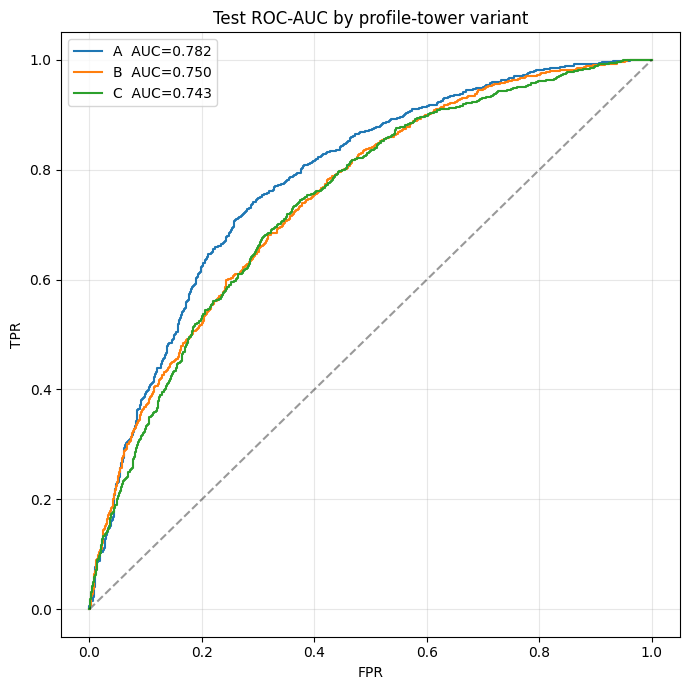

variant test_AUC test_acc  trainable_params  embedding_params
      A   0.7815   0.7238              2353                 0
      B   0.7501   0.6802              2173                92
      C   0.7428   0.6837              2183               134


In [11]:
#
# Test-set ROC curves (one figure) + summary table
#
res = [resA, resB, resC]
plt.figure(figsize=(7, 7))
for r in res:
    fpr, tpr, _ = roc_curve(yte, r["pred"])
    plt.plot(fpr, tpr, label=f"{r['variant']}  AUC={r['tex_auc']:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=.4)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Test ROC-AUC by profile-tower variant")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

rows = []
for r in res:
    rows.append([r["variant"], f"{r['tex_auc']:.4f}", f"{r['tex_acc']:.4f}",
                 r["model"].count_params(), embedded_params(r["model"])])
import pandas as pd
sumtab = pd.DataFrame(rows, columns=["variant", "test_AUC", "test_acc", "trainable_params", "embedding_params"])
print(sumtab.to_string(index=False))

Variant A train_auc: [0.7402, 0.754, 0.7529, 0.7666, 0.7743, 0.7823, 0.7803, 0.7419, 0.7839, 0.798]
Variant A val_auc  : [0.7436, 0.7516, 0.7517, 0.7585, 0.7645, 0.7724, 0.7741, 0.7466, 0.7771, 0.7865]
Variant B train_auc: [0.7101, 0.7349, 0.7515, 0.7622, 0.7439, 0.7239, 0.7407, 0.7549, 0.7654, 0.7695]
Variant B val_auc  : [0.7145, 0.7392, 0.7519, 0.7657, 0.7386, 0.7169, 0.7371, 0.7473, 0.7634, 0.7667]
Variant C train_auc: [0.7052, 0.7491, 0.7522, 0.7571, 0.75, 0.7584, 0.7639, 0.7579, 0.7484, 0.7593]
Variant C val_auc  : [0.7131, 0.7472, 0.7516, 0.7515, 0.7442, 0.7488, 0.7596, 0.746, 0.7405, 0.7524]


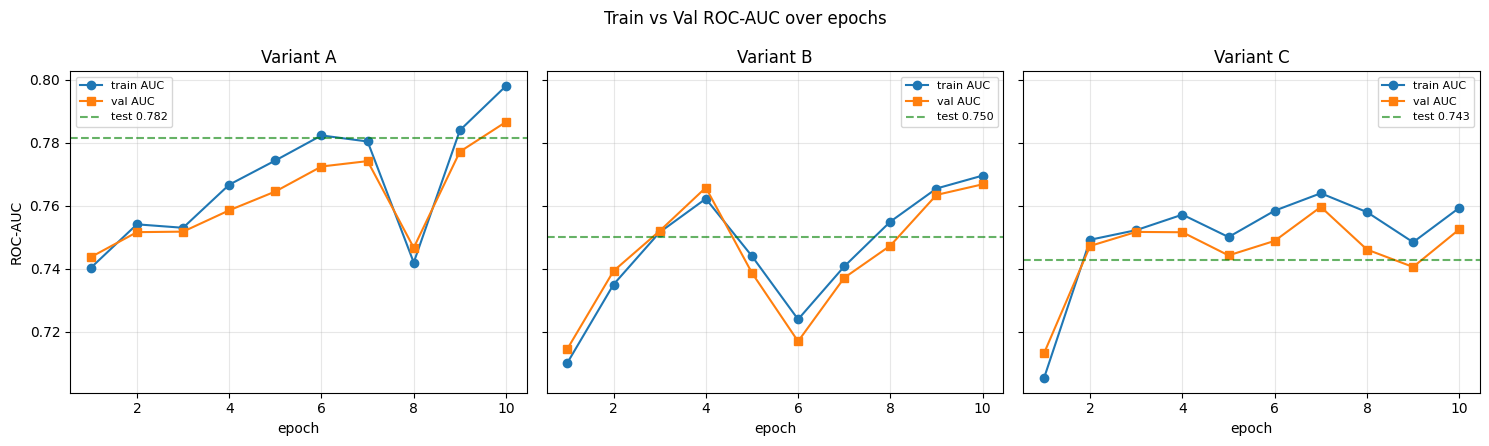

In [12]:
#
# Train-vs-Val ROC-AUC curves (one subplot per variant)
#
for r in res:
    print(f"Variant {r['variant']} train_auc: {[round(x,4) for x in r['train_auc']]}")
    print(f"Variant {r['variant']} val_auc  : {[round(x,4) for x in r['val_auc']]}")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, r in zip(axes, res):
    ep = np.arange(1, 11)
    ax.plot(ep, r["train_auc"], "o-", label="train AUC")
    ax.plot(ep, r["val_auc"],   "s-", label="val AUC")
    ax.axhline(r["tex_auc"], color="g", ls="--", alpha=.6, label=f"test {r['tex_auc']:.3f}")
    ax.set_title(f"Variant {r['variant']}")
    ax.set_xlabel("epoch")
    ax.legend(fontsize=8); ax.grid(alpha=.3)
axes[0].set_ylabel("ROC-AUC")
fig.suptitle("Train vs Val ROC-AUC over epochs")
plt.tight_layout(); plt.show()

## Reading the results

The table above is the headline. Read the train-vs-val curves together with it:

- **If a variant's val AUC plateaus high AND its test AUC is high**, it generalizes (good).
- **If train AUC keeps climbing while val/test plateau**, it is **overfitting** to training.

Note the variants are not parameter-equivalent: the embedding towers (B, C) push the categoricals through a
compressed dense vector (fewer weights into `Dense(16)`), which can act as implicit regularization on the
long-tail categories. Whether that outweighs one-hot here is exactly the empirical question this run answers —
and the embeddedParams / trainable_params columns show how much of the model is actually being learned.
